In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# regressors
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import scale, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [6]:
micro = pd.read_csv('micro_predicted.csv')
dunk = pd.read_csv('dunking-data.csv')

In [7]:
micro['predicted_biscuit'].value_counts()

predicted_biscuit
Rich Tea     177
Digestive    170
Hobnob       153
Name: count, dtype: int64

In [8]:
biscuit_colours = {
    'Digestive': 'red',
    'Hobnob': 'orange',
    'Rich Tea': 'blue'
}

## Rechecking PCA

[0.32568063 0.18820644 0.17282914 0.16143959 0.14441669 0.00742752]


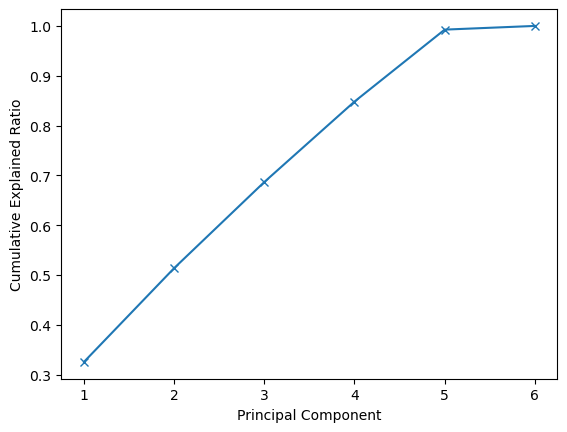

In [17]:
scaled_data = scale(micro.drop(columns=micro.filter(regex="^pr").columns))

pca = PCA(n_components = 6)
pca.fit(scaled_data)

pca_micro = pca.fit_transform(scaled_data)

# See explained variances

fig,ax = plt.subplots()

print(pca.explained_variance_ratio_)

ax.plot(np.arange(1,7), np.cumsum(pca.explained_variance_ratio_), marker = 'x')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Ratio')
ax.set_xticks([1,2,3,4,5,6])

plt.show()

It is clear that even with radius PCA is still not a suitable approach for classifying/ interpreting this data

# Radius Analysis 

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_395357/261881888.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


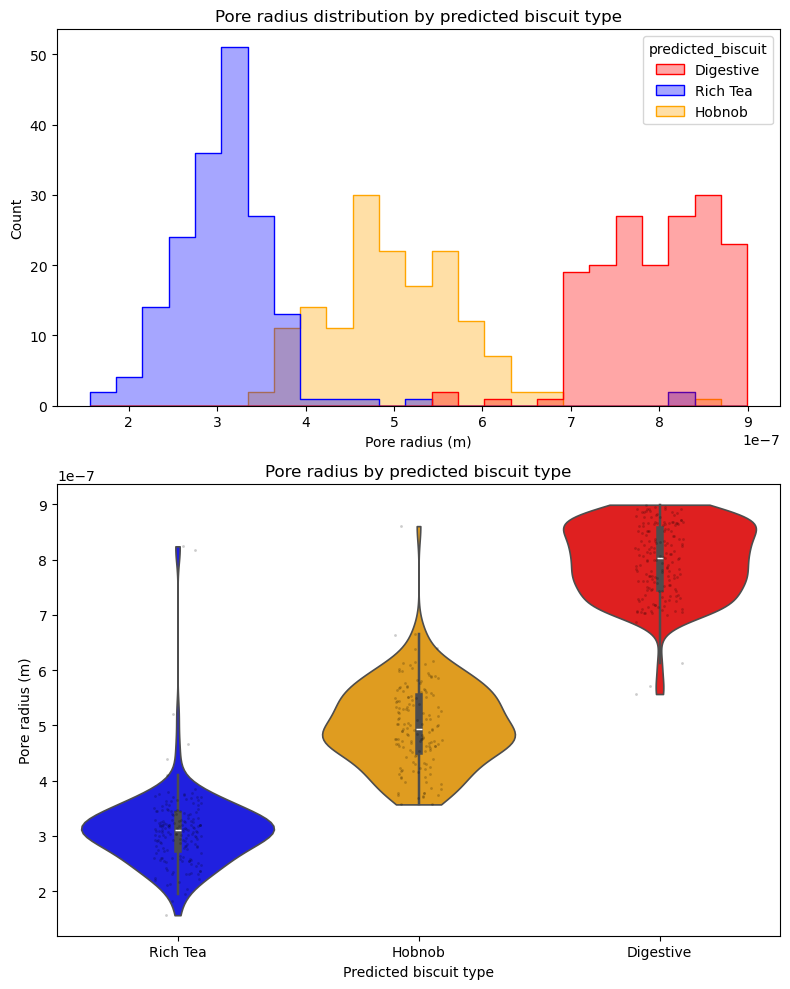

In [22]:
plt.tight_layout()
radius_col = 'r' 
class_col = 'predicted_biscuit'

order = ['Rich Tea','Hobnob','Digestive']

plt.show()


fig, axes = plt.subplots(
    2, 1, figsize=(8, 10),
    gridspec_kw={'height_ratios': [1, 1.2]}
)

# Histogram
sns.histplot(
    data=micro,
    x=radius_col,
    hue=class_col,
    palette=biscuit_colours,
    bins=25,
    element='step',
    stat='count',
    alpha=0.35,
    ax=axes[0]
)

axes[0].set_title('Pore radius distribution by predicted biscuit type')
axes[0].set_xlabel('Pore radius (m)')
axes[0].set_ylabel('Count')

# Violin
sns.violinplot(
    data=micro,
    x=class_col,
    y=radius_col,
    order=order,
    palette=biscuit_colours,
    inner='box',
    cut=0,
    linewidth=1.2,
    ax=axes[1]
)

sns.stripplot(
    data=micro,
    x=class_col,
    y=radius_col,
    order=order,
    color='black',
    alpha=0.2,
    size=2,
    ax=axes[1]
)

axes[1].set_title('Pore radius by predicted biscuit type')
axes[1].set_xlabel('Predicted biscuit type')
axes[1].set_ylabel('Pore radius (m)')

plt.tight_layout()
plt.show()

In [18]:
means = []
variances = []

for biscuit in np.unique(micro['predicted_biscuit']):
    variance = np.var(micro[micro['predicted_biscuit'] == biscuit]['r'])
    mean = np.mean(micro[micro['predicted_biscuit'] == biscuit]['r'])
    means.append(mean)
    variances.append(variance)

means_vars = pd.DataFrame(data = {'predicted_biscuit':np.unique(micro['predicted_biscuit']),
                                   'mean': means,
                                  'variance':variances})
means_vars

,predicted_biscuit,mean,variance
0,Digestive,7.978603e-07,4.266631e-15
1,Hobnob,4.999955e-07,5.717780e-15
2,Rich Tea,3.113405e-07,5.476797e-15


Digestive > Hobnob > Rich Tea in effective radius, as seen from rad table and violin/hist plots. This furthers the conc that these biscuits have meaningful structural differences that informs L

# Radius Estimation

This section aims to investigate whether ML can be used to deduce the radius of a biscuit retroactively from the microscopy data in the hope to make the prediction more valuable. This is not included in the final report as did not aide the narrative 

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

In [24]:

radius_features = ['gamma', 'phi', 'eta', 'L', 't']
X = micro[radius_features]
y = micro['r']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

radius_models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )
}

radius_results = []
radius_predictions = {}

for name, model in radius_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    radius_predictions[name] = pred
    
    radius_results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

pd.DataFrame(radius_results)

,Model,RMSE,MAE,R2
0,Linear Regression,1.276659e-07,1.018149e-07,0.639781
1,Random Forest,1.242317e-07,9.784027e-08,0.658900


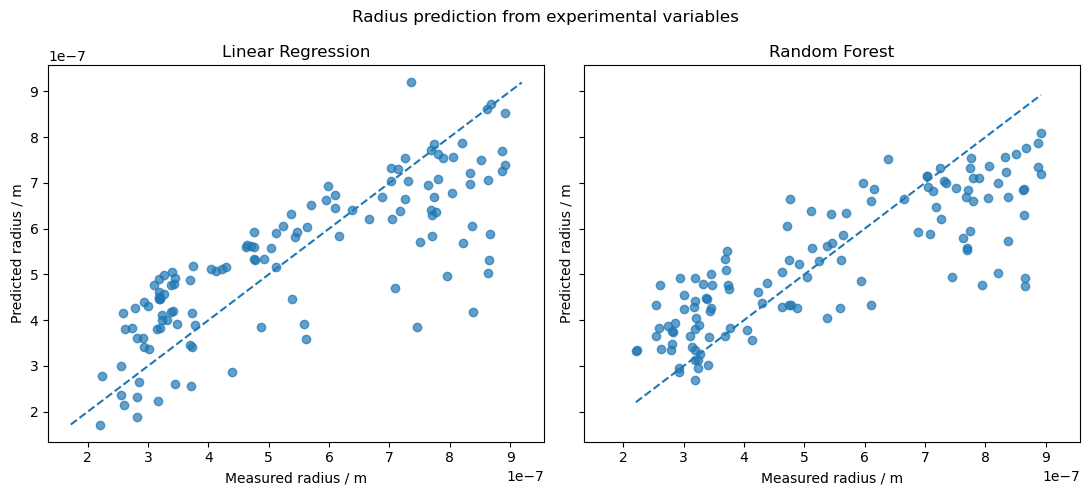

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes, radius_predictions.items()):
    ax.scatter(y_test, pred, alpha=0.7)
    
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    
    ax.set_title(name)
    ax.set_xlabel('Measured radius / m')
    ax.set_ylabel('Predicted radius / m')



fig.suptitle('Radius prediction from experimental variables')
fig.tight_layout()
plt.show()

# Comparison With Washburn

In [26]:
def washburn_L(gamma, r, t, phi, eta):
    value = (gamma * r * t * np.cos(phi)) / (2 * eta)
    return np.sqrt(np.maximum(value, 0))